In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import LSTM, Dense, Attention, Concatenate, Embedding, Bidirectional
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print('GPU detectee' if gpus else 'Aucun GPU detecte, entrainement sur CPU', gpus)

GPU detectee [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
SQUAD_CANDIDATES = ['train-v1.1.json', 'train-v1_1.json']
squad_path = next((p for p in SQUAD_CANDIDATES if os.path.exists(p)), SQUAD_CANDIDATES[0])

with open(squad_path, encoding='utf-8') as file_obj:
    squad_json = json.load(file_obj)

MAX_EXAMPLES = 30000
CONTEXT_WINDOW = 220

def windowed_context(context_text, answer_start, answer_text, window=CONTEXT_WINDOW):
    answer_end = answer_start + len(answer_text)
    center = (answer_start + answer_end) // 2
    half = window // 2
    start = max(0, center - half)
    end = start + window
    if end > len(context_text):
        end = len(context_text)
        start = max(0, end - window)
    return context_text[start:end]

pairs = []
for article in tqdm(squad_json['data'], desc='Lecture SQuAD'):
    for paragraph in article['paragraphs']:
        context_text = paragraph['context'].strip()
        for qa_item in paragraph['qas']:
            if not qa_item.get('answers'):
                continue
            question_text = qa_item['question'].strip()
            first_answer = qa_item['answers'][0]
            answer_text = first_answer['text'].strip()
            answer_start = first_answer.get('answer_start')
            if answer_start is None or not question_text or not answer_text:
                continue
            if len(question_text) >= 100 or len(answer_text) >= 50:
                continue
            context_window = windowed_context(context_text, answer_start, answer_text)
            if answer_text not in context_window:
                continue
            pairs.append((question_text, context_window, answer_text))

squad_df = pd.DataFrame(pairs, columns=['question', 'context', 'answer']).drop_duplicates().reset_index(drop=True)

if MAX_EXAMPLES is not None and len(squad_df) > MAX_EXAMPLES:
    squad_df = squad_df.sample(n=MAX_EXAMPLES, random_state=SEED).reset_index(drop=True)

print(squad_df.head())
print('Nombre de paires', len(squad_df))

Lecture SQuAD:   0%|          | 0/442 [00:00<?, ?it/s]

                                            question  \
0  When was the South Pacific Mandate for Japan a...   
1   What's the most recent generation of iPod Touch?   
2  How many players can an NFL team have in the o...   
3  How many counties does Oklahoma Cities Network...   
4  According to who was the defining moment of Ma...   

                                             context             answer  
0  Treaty of Versailles. It renounced all of its ...  December 17, 1920  
1  the iPod Touch was announced by Apple, and was...              sixth  
2   of August, are played for the purpose of help...                 90  
3  n the Oklahoma City market (ranked 41st for te...                 34  
4  According to Taraborrelli, the defining moment...      Taraborrelli,  
Nombre de paires 30000


                                               question  \
count                                             30000   
unique                                            29975   
top     In what year did Kanye West's mother pass away?   
freq                                                  2   

                                                  context answer  
count                                               30000  30000  
unique                                              28253  24215  
top     Victoria married her first cousin, Prince Albe...  three  
freq                                                    6     96  

Longueur question  - moyenne 56.8, mediane 56.0, max 99
Longueur contexte   - moyenne 219.5, mediane 220.0, max 220
Longueur reponse   - moyenne 15.0, mediane 13.0, max 49


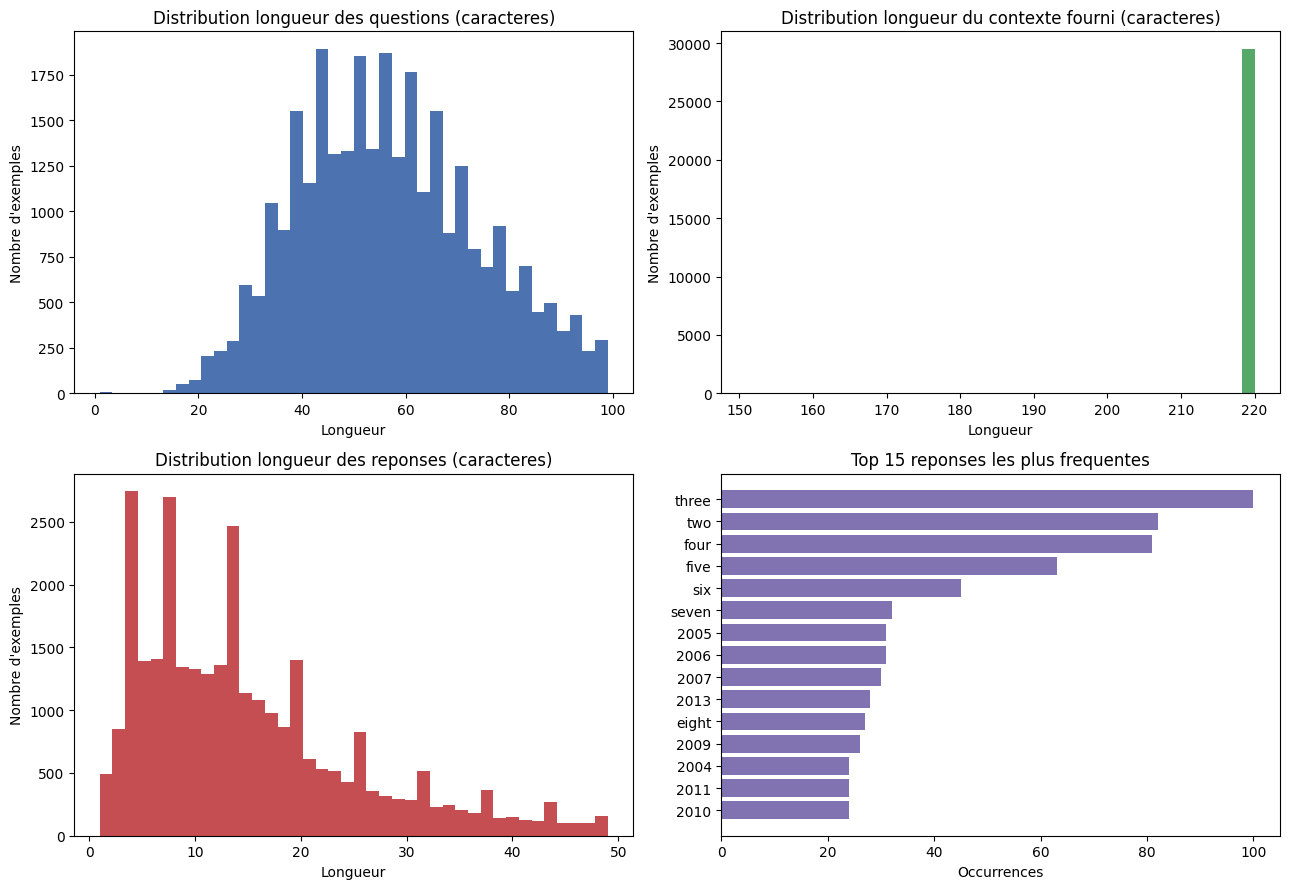

In [4]:
question_lengths = squad_df['question'].str.len()
context_lengths = squad_df['context'].str.len()
answer_lengths = squad_df['answer'].str.len()

print(squad_df[['question', 'context', 'answer']].describe(include='all'))
print()
print('Longueur question  - moyenne %.1f, mediane %.1f, max %d' % (question_lengths.mean(), question_lengths.median(), question_lengths.max()))
print('Longueur contexte   - moyenne %.1f, mediane %.1f, max %d' % (context_lengths.mean(), context_lengths.median(), context_lengths.max()))
print('Longueur reponse   - moyenne %.1f, mediane %.1f, max %d' % (answer_lengths.mean(), answer_lengths.median(), answer_lengths.max()))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(question_lengths, bins=40, color='#4C72B0')
axes[0, 0].set_title('Distribution longueur des questions (caracteres)')
axes[0, 0].set_xlabel('Longueur')
axes[0, 0].set_ylabel('Nombre d\'exemples')

axes[0, 1].hist(context_lengths, bins=40, color='#55A868')
axes[0, 1].set_title('Distribution longueur du contexte fourni (caracteres)')
axes[0, 1].set_xlabel('Longueur')
axes[0, 1].set_ylabel('Nombre d\'exemples')

axes[1, 0].hist(answer_lengths, bins=40, color='#C44E52')
axes[1, 0].set_title('Distribution longueur des reponses (caracteres)')
axes[1, 0].set_xlabel('Longueur')
axes[1, 0].set_ylabel('Nombre d\'exemples')

top_answers = squad_df['answer'].str.lower().value_counts().head(15)
axes[1, 1].barh(top_answers.index[::-1], top_answers.values[::-1], color='#8172B2')
axes[1, 1].set_title('Top 15 reponses les plus frequentes')
axes[1, 1].set_xlabel('Occurrences')

plt.tight_layout()
plt.show()

In [5]:
PAD_TOKEN = '<PAD>'
START_TOKEN = '<START>'
END_TOKEN = '<END>'
SEP_TOKEN = '<SEP>'

MAX_SOURCE_LEN = 320
MAX_ANSWER_CHARS = 49
MAX_TARGET_LEN = MAX_ANSWER_CHARS + 1
BATCH_SIZE = 128
EPOCHS = 45

squad_df['source'] = squad_df['question'] + ' ' + SEP_TOKEN + ' ' + squad_df['context']

source_chars = sorted(set(''.join(squad_df['source'].tolist())))
target_chars = sorted(set(''.join(squad_df['answer'].tolist())))

vocab_enc = [PAD_TOKEN] + source_chars
vocab_dec = [PAD_TOKEN, START_TOKEN, END_TOKEN] + target_chars

enc_char_to_id = {char: idx for idx, char in enumerate(vocab_enc)}
dec_char_to_id = {char: idx for idx, char in enumerate(vocab_dec)}
dec_id_to_char = {idx: char for char, idx in dec_char_to_id.items()}

VOCAB_ENC_SIZE = len(vocab_enc)
VOCAB_DEC_SIZE = len(vocab_dec)
PAD_ID = dec_char_to_id[PAD_TOKEN]

print('Vocabulaire encodeur', VOCAB_ENC_SIZE)
print('Vocabulaire decodeur', VOCAB_DEC_SIZE)

Vocabulaire encodeur 873
Vocabulaire decodeur 236


In [6]:
def encode_source(source_text):
    source_ids = [enc_char_to_id[char] for char in source_text[:MAX_SOURCE_LEN]]
    source_ids += [enc_char_to_id[PAD_TOKEN]] * (MAX_SOURCE_LEN - len(source_ids))
    return source_ids


def encode_target(answer_text):
    answer_ids = [dec_char_to_id[char] for char in answer_text[:MAX_ANSWER_CHARS]]
    decoder_input = [dec_char_to_id[START_TOKEN]] + answer_ids
    decoder_target = answer_ids + [dec_char_to_id[END_TOKEN]]
    decoder_input += [PAD_ID] * (MAX_TARGET_LEN - len(decoder_input))
    decoder_target += [PAD_ID] * (MAX_TARGET_LEN - len(decoder_target))
    return decoder_input, decoder_target

source_integer_data = np.asarray(
    [encode_source(source_text) for source_text in tqdm(squad_df['source'], desc='Encodage sources')],
    dtype=np.int32
)

decoder_input_integer_data = []
decoder_target_integer_data = []
for answer_text in tqdm(squad_df['answer'], desc='Preparation teacher forcing'):
    input_row, target_row = encode_target(answer_text)
    decoder_input_integer_data.append(input_row)
    decoder_target_integer_data.append(target_row)

decoder_input_integer_data = np.asarray(decoder_input_integer_data, dtype=np.int32)
decoder_target_integer_data = np.asarray(decoder_target_integer_data, dtype=np.int32)

all_indices = np.arange(len(squad_df))
train_indices, test_indices = train_test_split(all_indices, test_size=0.10, random_state=SEED)
train_indices, valid_indices = train_test_split(train_indices, test_size=0.10, random_state=SEED)

Encodage sources:   0%|          | 0/30000 [00:00<?, ?it/s]

Preparation teacher forcing:   0%|          | 0/30000 [00:00<?, ?it/s]

In [7]:
def make_dataset(sample_indices, shuffle=False):
    source_values = source_integer_data[sample_indices]
    decoder_values = decoder_input_integer_data[sample_indices]
    target_values = decoder_target_integer_data[sample_indices]
    dataset = tf.data.Dataset.from_tensor_slices(((source_values, decoder_values), target_values))
    if shuffle:
        dataset = dataset.shuffle(min(len(sample_indices), 20000), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(BATCH_SIZE, drop_remainder=False)
    return dataset.prefetch(tf.data.AUTOTUNE)

train_dataset = make_dataset(train_indices, shuffle=True)
valid_dataset = make_dataset(valid_indices, shuffle=False)

In [8]:
EMBEDDING_DIM = 128

encoder_inputs = Input(shape=(MAX_SOURCE_LEN,), dtype='int32', name='encoder_inputs')
encoder_embedding = Embedding(VOCAB_ENC_SIZE, EMBEDDING_DIM, name='encoder_embedding')
encoder_embedded = encoder_embedding(encoder_inputs)
encoder_bilstm = Bidirectional(
    LSTM(128, return_sequences=True, return_state=True), name='encoder_bilstm'
)
encoder_sequence, fwd_h, fwd_c, bwd_h, bwd_c = encoder_bilstm(encoder_embedded)
state_h = Concatenate(name='encoder_state_h')([fwd_h, bwd_h])
state_c = Concatenate(name='encoder_state_c')([fwd_c, bwd_c])

decoder_inputs = Input(shape=(MAX_TARGET_LEN,), dtype='int32', name='decoder_inputs')
decoder_embedding = Embedding(VOCAB_DEC_SIZE, EMBEDDING_DIM, name='decoder_embedding')
decoder_embedded = decoder_embedding(decoder_inputs)
decoder_lstm = LSTM(256, return_sequences=True, return_state=True, name='decoder_lstm')
decoder_sequence, _, _ = decoder_lstm(decoder_embedded, initial_state=[state_h, state_c])

attention_output = Attention(name='source_attention')([decoder_sequence, encoder_sequence])
merged_sequence = Concatenate(name='decoder_attention_concat')([decoder_sequence, attention_output])
decoder_outputs = Dense(VOCAB_DEC_SIZE, activation='softmax', name='character_classifier')(merged_sequence)

attention_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
attention_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 320)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 320, 128)  │    111,744 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_bilstm      │ [(None, 320,      │    263,168 │ encoder_embeddin… │
│ (Bidirectional)     │ 256), (None,      │            │                   │
│                     │ 128), (None,      │            │                   │
│                     │ 128), (None,      │            │                   │
│                     │ 128), (None,      │            │                   │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 50, 128)   │     30,208 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_state_h     │ (None, 256)       │          0 │ encoder_bilstm[0… │
│ (Concatenate)       │                   │            │ encoder_bilstm[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_state_c     │ (None, 256)       │          0 │ encoder_bilstm[0… │
│ (Concatenate)       │                   │            │ encoder_bilstm[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 50, 256), │    394,240 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ encoder_state_h[… │
│                     │ (None, 256)]      │            │ encoder_state_c[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ source_attention    │ (None, 50, 256)   │          0 │ decoder_lstm[0][… │
│ (Attention)         │                   │            │ encoder_bilstm[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_attention_… │ (None, 50, 512)   │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ source_attention… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ character_classifi… │ (None, 50, 236)   │    121,068 │ decoder_attentio… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 920,428 (3.51 MB)

 Trainable params: 920,428 (3.51 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
def masked_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    losses = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), losses.dtype)
    return tf.reduce_sum(losses * mask) / tf.maximum(tf.reduce_sum(mask), 1.0)


def masked_accuracy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    predicted_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
    mask = tf.not_equal(y_true, PAD_ID)
    correct = tf.logical_and(tf.equal(y_true, predicted_ids), mask)
    return tf.reduce_sum(tf.cast(correct, tf.float32)) / tf.maximum(tf.reduce_sum(tf.cast(mask, tf.float32)), 1.0)


def sequence_exact_match(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    predicted_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
    mask = tf.not_equal(y_true, PAD_ID)
    correct_tokens = tf.logical_or(tf.equal(y_true, predicted_ids), tf.logical_not(mask))
    complete_sequences = tf.reduce_all(correct_tokens, axis=-1)
    return tf.reduce_mean(tf.cast(complete_sequences, tf.float32))


def masked_perplexity(y_true, y_pred):
    return tf.exp(masked_loss(y_true, y_pred))

attention_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
    loss=masked_loss,
    metrics=[masked_accuracy, sequence_exact_match, masked_perplexity]
)

class EpochReport(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        learning_rate = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        print(
            f"Epoque {epoch + 1:02d} - "
            f"loss {logs.get('loss', float('nan')):.4f} - "
            f"val_loss {logs.get('val_loss', float('nan')):.4f} - "
            f"accuracy caracteres {logs.get('masked_accuracy', float('nan')):.4f} - "
            f"val_accuracy caracteres {logs.get('val_masked_accuracy', float('nan')):.4f} - "
            f"exact-match teacher forcing {logs.get('sequence_exact_match', float('nan')):.4f} - "
            f"val_exact-match teacher forcing {logs.get('val_sequence_exact_match', float('nan')):.4f} - "
            f"perplexite {logs.get('masked_perplexity', float('nan')):.3f} - "
            f"learning rate {learning_rate:.2e}"
        )

history = attention_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    callbacks=[
        EpochReport(),
        ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-5, verbose=1),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

Epoch 1/45


190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 3.7223 - masked_accuracy: 0.1095 - masked_perplexity: 62.6636 - sequence_exact_match: 1.5185e-05Epoque 01 - loss 3.2301 - val_loss 2.7756 - accuracy caracteres 0.1543 - val_accuracy caracteres 0.2144 - exact-match teacher forcing 0.0001 - val_exact-match teacher forcing 0.0000 - perplexite 32.049 - learning rate 5.00e-04
190/190 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - loss: 3.2301 - masked_accuracy: 0.1543 - masked_perplexity: 32.0487 - sequence_exact_match: 8.2237e-05 - val_loss: 2.7756 - val_masked_accuracy: 0.2144 - val_masked_perplexity: 16.0717 - val_sequence_exact_match: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/45
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 2.7117 - masked_accuracy: 0.2264 - masked_perplexity: 15.0755 - sequence_exact_match: 1.3012e-04Epoque 02 - loss 2.6691 - val_loss 2.5990 - accuracy caracteres 0.2369 - val_accuracy caracteres 0.2596 - exact-match teacher forcing 0.0001 - val_exact-match teacher forcin

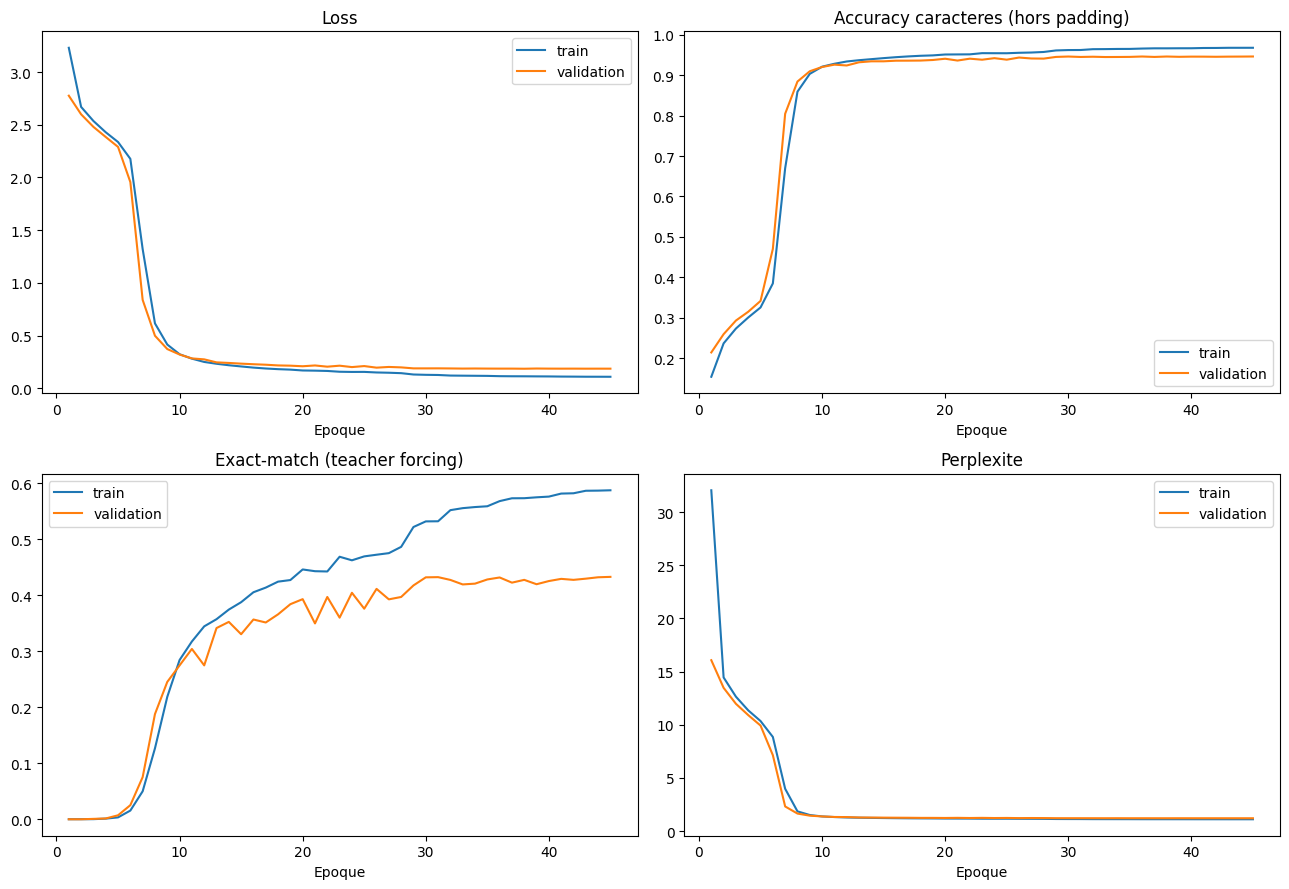

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
epochs_range = range(1, len(history.history['loss']) + 1)

axes[0, 0].plot(epochs_range, history.history['loss'], label='train')
axes[0, 0].plot(epochs_range, history.history['val_loss'], label='validation')
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epoque')
axes[0, 0].legend()

axes[0, 1].plot(epochs_range, history.history['masked_accuracy'], label='train')
axes[0, 1].plot(epochs_range, history.history['val_masked_accuracy'], label='validation')
axes[0, 1].set_title('Accuracy caracteres (hors padding)')
axes[0, 1].set_xlabel('Epoque')
axes[0, 1].legend()

axes[1, 0].plot(epochs_range, history.history['sequence_exact_match'], label='train')
axes[1, 0].plot(epochs_range, history.history['val_sequence_exact_match'], label='validation')
axes[1, 0].set_title('Exact-match (teacher forcing)')
axes[1, 0].set_xlabel('Epoque')
axes[1, 0].legend()

axes[1, 1].plot(epochs_range, history.history['masked_perplexity'], label='train')
axes[1, 1].plot(epochs_range, history.history['val_masked_perplexity'], label='validation')
axes[1, 1].set_title('Perplexite')
axes[1, 1].set_xlabel('Epoque')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [11]:
inference_encoder = Model(encoder_inputs, [encoder_sequence, state_h, state_c])

one_step_token = Input(shape=(1,), dtype='int32', name='one_step_token')
input_state_h = Input(shape=(256,), name='input_state_h')
input_state_c = Input(shape=(256,), name='input_state_c')
input_encoder_sequence = Input(shape=(MAX_SOURCE_LEN, 256), name='input_encoder_sequence')

one_step_embedded = decoder_embedding(one_step_token)
step_decoder_sequence, next_h, next_c = decoder_lstm(
    one_step_embedded,
    initial_state=[input_state_h, input_state_c]
)
step_attention = Attention()([step_decoder_sequence, input_encoder_sequence])
step_merged = Concatenate()([step_decoder_sequence, step_attention])
step_output = attention_model.get_layer('character_classifier')(step_merged)

inference_decoder = Model(
    [one_step_token, input_state_h, input_state_c, input_encoder_sequence],
    [step_output, next_h, next_c]
)


def encode_source_ids(source_text):
    return np.asarray([encode_source(source_text)], dtype=np.int32)


def has_repetition(chars, min_pattern_len=3, max_pattern_len=25, repeats=3):
    text = ''.join(chars)
    for pattern_len in range(min_pattern_len, max_pattern_len + 1):
        needed = pattern_len * repeats
        if len(text) < needed:
            continue
        tail = text[-needed:]
        pattern = tail[:pattern_len]
        if pattern * repeats == tail:
            return True
    return False


def answer_question(question_text, context_text, max_length=MAX_ANSWER_CHARS):
    source_text = question_text + ' ' + SEP_TOKEN + ' ' + context_text
    source_input = encode_source_ids(source_text)
    encoder_values, state_h_value, state_c_value = inference_encoder.predict(source_input, verbose=0)

    current_id = dec_char_to_id[START_TOKEN]
    generated_chars = []

    for _ in range(max_length + 1):
        token_input = np.asarray([[current_id]], dtype=np.int32)
        prediction, state_h_value, state_c_value = inference_decoder.predict(
            [token_input, state_h_value, state_c_value, encoder_values], verbose=0
        )
        next_id = int(np.argmax(prediction[0, 0]))
        next_token = dec_id_to_char[next_id]

        if next_token == END_TOKEN:
            break
        if next_token not in (PAD_TOKEN, START_TOKEN):
            generated_chars.append(next_token)
            if has_repetition(generated_chars):
                break
        current_id = next_id

    return ''.join(generated_chars).strip() or '[reponse vide]'


def beam_search_answer(question_text, context_text, beam_width=3, max_length=MAX_ANSWER_CHARS):
    source_text = question_text + ' ' + SEP_TOKEN + ' ' + context_text
    source_input = encode_source_ids(source_text)
    encoder_values, init_h, init_c = inference_encoder.predict(source_input, verbose=0)

    start_id = dec_char_to_id[START_TOKEN]
    end_id = dec_char_to_id[END_TOKEN]

    beams = [(0.0, [start_id], init_h, init_c, False)]

    for _ in range(max_length + 1):
        candidates = []
        active_beams = False
        for log_prob, token_ids, h_value, c_value, finished in beams:
            if finished:
                candidates.append((log_prob, token_ids, h_value, c_value, finished))
                continue
            active_beams = True
            token_input = np.asarray([[token_ids[-1]]], dtype=np.int32)
            prediction, next_h, next_c = inference_decoder.predict(
                [token_input, h_value, c_value, encoder_values], verbose=0
            )
            probs = prediction[0, 0]
            top_ids = np.argsort(probs)[-beam_width:]
            for next_id in top_ids:
                next_id = int(next_id)
                next_log_prob = log_prob + float(np.log(probs[next_id] + 1e-8))
                is_finished = next_id == end_id
                candidates.append((next_log_prob, token_ids + [next_id], next_h, next_c, is_finished))

        if not active_beams:
            break
        candidates.sort(key=lambda item: item[0], reverse=True)
        beams = candidates[:beam_width]

    best_tokens = max(beams, key=lambda item: item[0])[1]
    generated_chars = []
    for token_id in best_tokens[1:]:
        token_char = dec_id_to_char[token_id]
        if token_char == END_TOKEN:
            break
        if token_char not in (PAD_TOKEN, START_TOKEN):
            generated_chars.append(token_char)
            if has_repetition(generated_chars):
                break

    return ''.join(generated_chars).strip() or '[reponse vide]'


def batch_answer_questions(question_context_pairs, batch_size=128, max_length=MAX_ANSWER_CHARS):
    predictions = [None] * len(question_context_pairs)
    start_id = dec_char_to_id[START_TOKEN]
    end_id = dec_char_to_id[END_TOKEN]

    for chunk_start in range(0, len(question_context_pairs), batch_size):
        chunk = question_context_pairs[chunk_start:chunk_start + batch_size]
        source_texts = [q + ' ' + SEP_TOKEN + ' ' + c for q, c in chunk]
        source_ids = np.asarray([encode_source(t) for t in source_texts], dtype=np.int32)
        encoder_values, state_h_value, state_c_value = inference_encoder.predict(source_ids, verbose=0)

        batch_n = len(chunk)
        current_ids = np.full((batch_n, 1), start_id, dtype=np.int32)
        finished = np.zeros(batch_n, dtype=bool)
        generated = [[] for _ in range(batch_n)]

        for _ in range(max_length + 1):
            prediction, state_h_value, state_c_value = inference_decoder.predict(
                [current_ids, state_h_value, state_c_value, encoder_values], verbose=0
            )
            next_ids = np.argmax(prediction[:, 0, :], axis=-1)
            for i in range(batch_n):
                if finished[i]:
                    continue
                next_token = dec_id_to_char[int(next_ids[i])]
                if next_token == end_id or next_token == END_TOKEN:
                    finished[i] = True
                    continue
                if next_token not in (PAD_TOKEN, START_TOKEN):
                    generated[i].append(next_token)
                    if has_repetition(generated[i]):
                        finished[i] = True
            current_ids = next_ids.reshape(-1, 1).astype(np.int32)
            if finished.all():
                break

        for i in range(batch_n):
            predictions[chunk_start + i] = ''.join(generated[i]).strip() or '[reponse vide]'

    return predictions

In [12]:
preview_indices = test_indices[:10]
preview_source = [(squad_df.iloc[i]['question'], squad_df.iloc[i]['context']) for i in preview_indices]
greedy_predictions = batch_answer_questions(preview_source)

preview_rows = []
for row_index, greedy_prediction in tqdm(list(zip(preview_indices, greedy_predictions)), desc='Predictions'):
    row = squad_df.iloc[row_index]
    beam_prediction = beam_search_answer(row['question'], row['context'])
    preview_rows.append({
        'question': row['question'],
        'reponse attendue': row['answer'],
        'reponse predite (greedy)': greedy_prediction,
        'reponse predite (beam search)': beam_prediction
    })

predictions_df = pd.DataFrame(preview_rows)
print(predictions_df.to_string(index=False))

Predictions:   0%|          | 0/10 [00:00<?, ?it/s]

                                                                      question       reponse attendue                           reponse predite (greedy)                  reponse predite (beam search)
                               Insects move by walking, flying, and what else?               swimming                                                see                                            see
In the conflict, who lead the German states of the North German Confederation? the Kingdom of Prussia                                 Kingdom of Prussia                             Kingdom of Prussia
     A zero inflation policy would limit who's influence and ability to react?           central bank a policy limits the ability of the central bank to                                  policy limits
                                        How far from Valencia is the Albufera?                  11 km                                              11 km                                          11 km


Exact-match beam search:   0%|          | 0/60 [00:00<?, ?it/s]

Exact-match greedy sur 300 exemples : 0.5233
Exact-match beam search sur 60 exemples : 0.6000


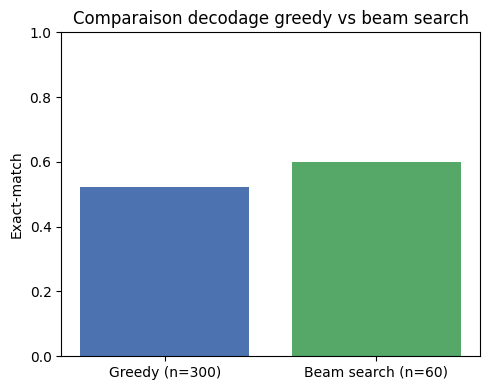

In [13]:
import re
import string

def normalize_text(text_value):
    text_value = str(text_value).lower().strip()
    text_value = ''.join(char for char in text_value if char not in string.punctuation)
    text_value = re.sub(r'\b(a|an|the)\b', ' ', text_value)
    return ' '.join(text_value.split())

GREEDY_EVAL_SIZE = 300
BEAM_EVAL_SIZE = 60

greedy_eval_indices = test_indices[:GREEDY_EVAL_SIZE]
greedy_eval_source = [(squad_df.iloc[i]['question'], squad_df.iloc[i]['context']) for i in greedy_eval_indices]
greedy_predictions = batch_answer_questions(greedy_eval_source)
greedy_expected = [normalize_text(squad_df.iloc[i]['answer']) for i in greedy_eval_indices]
greedy_matches = [normalize_text(pred) == exp for pred, exp in zip(greedy_predictions, greedy_expected)]

beam_matches = []
for row_index in tqdm(test_indices[:BEAM_EVAL_SIZE], desc='Exact-match beam search'):
    row = squad_df.iloc[row_index]
    beam_prediction = beam_search_answer(row['question'], row['context'])
    beam_matches.append(normalize_text(beam_prediction) == normalize_text(row['answer']))

print(f'Exact-match greedy sur {GREEDY_EVAL_SIZE} exemples : {float(np.mean(greedy_matches)):.4f}')
print(f'Exact-match beam search sur {BEAM_EVAL_SIZE} exemples : {float(np.mean(beam_matches)):.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    [f'Greedy (n={GREEDY_EVAL_SIZE})', f'Beam search (n={BEAM_EVAL_SIZE})'],
    [np.mean(greedy_matches), np.mean(beam_matches)],
    color=['#4C72B0', '#55A868']
)
ax.set_ylabel('Exact-match')
ax.set_ylim(0, 1)
ax.set_title('Comparaison decodage greedy vs beam search')
plt.tight_layout()
plt.show()